In [1]:


import unittest
import torch
from scipy.optimize import minimize
from src.estimation_torch import GPPEstimation  # Assuming your class is defined in gppestimation.py
from src.generation import GPPSampleGenerator
from sklearn.gaussian_process.kernels import Matern
import math
from src.kernel import exponential_kernel,onedif_kernel
from src.networks import generate_connected_erdos_renyi_graph
from src.weights import optimal_weight_matrix
import networkx as nx
import numpy as np
import random
import pickle
from functools import partial
import multiprocessing
import matplotlib.pyplot as plt
import os


In [2]:
#change work directory
path_project="/home/shij0d/Documents/Dis_Spatial"
os.chdir(path_project)


In [3]:
with open(f'real_data/Second_scenario/time_com_varying_m/time_com_varying_m_fixed_J.pkl', 'rb') as f:
        results=pickle.load(f)
ms=[60,70,80,90,100,150,200,250]
ms=np.array(ms)
R=5
elapsed_times_mle=torch.zeros((len(ms),R),dtype=torch.double)
elapsed_times_de=torch.zeros((len(ms),R),dtype=torch.double)
for m in range(len(ms)):
    for r in range(R):
        elapsed_times_mle[m,r]=results[m][r][0]
        elapsed_times_de[m,r]=results[m][r][1]
#elapsed_times_mle=elapsed_times_mle.flatten()
elapsed_times_mle=elapsed_times_mle[:5,:]

mle_mean = np.mean(elapsed_times_mle.numpy(),axis=1)
de_mean = np.mean(elapsed_times_de.numpy(), axis=1)

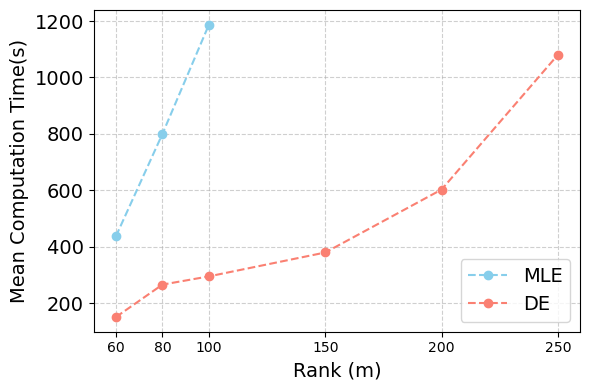

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ms[:5][[0,2,4]], mle_mean[[0,2,4]], 'o--', label='MLE', color='skyblue', markersize=6)
ax.plot(ms[[0,2,4,5,6,7]], de_mean[[0,2,4,5,6,7]], 'o--', label='DE', color='salmon', markersize=6)

ax.set_xticks(ms[[0,2,4,5,6,7]])
ax.set_xticklabels(ms[[0,2,4,5,6,7]],fontsize=10)
ax.tick_params(axis='y', labelsize=14)

# Customize plot
ax.set_xlabel('Rank (m)',fontsize=14)
ax.set_ylabel('Mean Computation Time(s)',fontsize=14)
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig("real_data/Second_scenario/time_com_varying_m/time_com_varying_m_fixed_J.pdf")
plt.show()